# Cellular Automata Model — Square Room, Top-Middle Exit

Implementation of the Burstedde et al. (2001) stochastic CA pedestrian model.  
**Scenario:** 10 m × 10 m square room, single 1 m exit centred on the top wall.  
Static floor field via BFS; dynamic floor field with decay and diffusion.  
Results shown as mean ± std over multiple realisations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation
from collections import deque
from IPython.display import HTML
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ── Domain ────────────────────────────────────────────────────────────────────
ROOM_W   = 10.0   # m
ROOM_H   = 10.0   # m
EXIT_W   = 1.0    # m, centred on top wall

# ── Grid ──────────────────────────────────────────────────────────────────────
# Each cell = 0.2 m × 0.2 m  →  50 × 50 grid = 10 m × 10 m
CELL_SIZE = 0.2   # m per cell
M         = int(ROOM_W / CELL_SIZE)   # = 50 columns and rows

# ── Crowd ─────────────────────────────────────────────────────────────────────
N_AGENTS  = 800   # initial number of pedestrians
N_RUNS    = 10   # independent realisations for statistics

# ── CA parameters ─────────────────────────────────────────────────────────────
k_S       = 3.0   # static floor field sensitivity
k_D       = 1.0   # dynamic floor field sensitivity
DELTA     = 0.1   # dynamic field decay rate per step
ALPHA_D   = 0.05  # dynamic field diffusion rate per step
INERTIA   = False # whether to prefer last move direction (keep False for simplicity)

# ── Time ──────────────────────────────────────────────────────────────────────
# Each CA step ≈ 0.3 s  (standard Burstedde calibration at 0.2 m cells)
DT_PHYS   = 0.3   # seconds per CA step
MAX_STEPS = 3000  # max steps before forced stop

# ── Output ────────────────────────────────────────────────────────────────────
PLOT_STEPS  = [0,1,2,5,10, 50, 150, 300, 600, 1200, 1800, 2400, 3000]  # CA steps for snapshots
ANIM_SKIP   = 10   # store every N-th step for animation

print(f"Grid:        {M} × {M} cells, cell size = {CELL_SIZE} m")
print(f"Room:        {ROOM_W} m × {ROOM_H} m")
print(f"Exit:        {EXIT_W} m wide, centred on top wall")
print(f"Agents:      {N_AGENTS}  initial density = {N_AGENTS/(M*M):.3f} per cell "
      f"= {N_AGENTS/(ROOM_W*ROOM_H):.1f} people/m²")
print(f"Runs:        {N_RUNS} independent realisations")

Grid:        50 × 50 cells, cell size = 0.2 m
Room:        10.0 m × 10.0 m
Exit:        1.0 m wide, centred on top wall
Agents:      50  initial density = 0.020 per cell = 0.5 people/m²
Runs:        1 independent realisations


Exit columns: 23–27  (5 cells = 1.0 m)


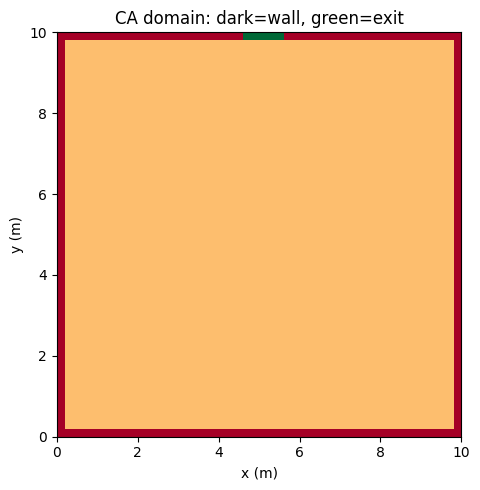

In [25]:
# ── Build domain masks ────────────────────────────────────────────────────────

wall = np.zeros((M, M), dtype=bool)
wall[0,  :] = True   # bottom row = wall (row index 0 = physical y=0)
wall[-1, :] = True   # top row = wall
wall[:,  0] = True   # left column
wall[:, -1] = True   # right column

# Exit: top wall, centred
exit_cells = max(1, round(EXIT_W / CELL_SIZE))   # = 5 cells
cx         = M // 2
ec0        = cx - exit_cells // 2
ec1        = ec0 + exit_cells
wall[-1, ec0:ec1]    = False   # open the wall
exit_mask = np.zeros((M, M), dtype=bool)
exit_mask[-1, ec0:ec1] = True

# Interior mask (cells pedestrians can occupy)
interior = ~wall & ~exit_mask

print(f"Exit columns: {ec0}–{ec1-1}  ({exit_cells} cells = {exit_cells*CELL_SIZE:.1f} m)")

# Quick visual check
fig, ax = plt.subplots(figsize=(5, 5))
vis = np.zeros((M, M))
vis[wall]      = -1
vis[exit_mask] =  2
ax.imshow(vis, origin='lower', cmap='RdYlGn', vmin=-1, vmax=2,
          extent=[0, ROOM_W, 0, ROOM_H])
ax.set_title('CA domain: dark=wall, green=exit'); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
plt.tight_layout(); plt.show()

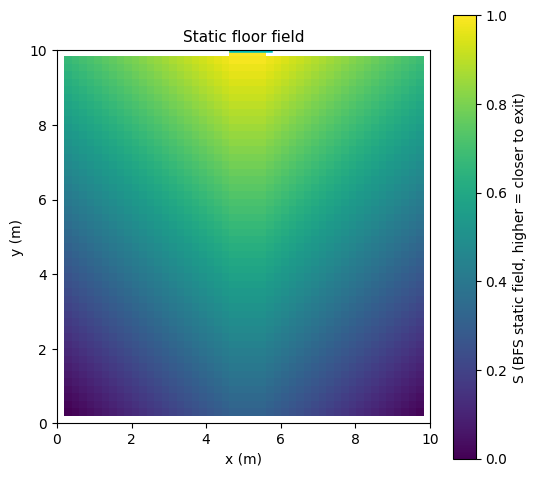

S range: 0.0 – 1.0


In [26]:
# ── Static floor field via BFS ─────────────────────────────────────────────────
# S[i,j] = (max_dist - BFS_dist_to_exit)  so cells near the exit have LARGE S

def build_static_field(wall, exit_mask):
    """BFS from all exit cells; returns S[i,j] = max_dist - dist_to_exit."""
    M = wall.shape[0]
    dist  = np.full((M, M), np.inf)
    queue = deque()

    # Seed BFS from every exit cell
    for i, j in zip(*np.where(exit_mask)):
        dist[i, j] = 0
        queue.append((i, j))

    dirs = [(-1,0),(1,0),(0,-1),(0,1)]   # 4-connected BFS (diagonals handled separately)
    while queue:
        i, j = queue.popleft()
        for di, dj in dirs:
            ni, nj = i+di, j+dj
            if 0 <= ni < M and 0 <= nj < M and not wall[ni,nj] and dist[ni,nj] == np.inf:
                dist[ni, nj] = dist[i, j] + 1
                queue.append((ni, nj))

    max_d = dist[np.isfinite(dist)].max()
    S = np.where(np.isfinite(dist), max_d - dist, 0.0)
    S[exit_mask] = max_d   # exit cells have highest value
    # Normalise to [0,1] so exp(k_S * S) stays finite
    if max_d > 0:
        S = S / max_d
    return S

S_field = build_static_field(wall, exit_mask)

# Visualise
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(np.ma.masked_where(wall, S_field), origin='lower', cmap='viridis',
               extent=[0, ROOM_W, 0, ROOM_H])
plt.colorbar(im, ax=ax, label='S (BFS static field, higher = closer to exit)')
ax.set_title('Static floor field', fontsize=11); ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.plot([(ec0+0.5)*CELL_SIZE, (ec1+0.5)*CELL_SIZE], [ROOM_H, ROOM_H], 'c-', lw=4)
plt.tight_layout(); plt.show()
print(f"S range: {S_field.min():.1f} – {S_field.max():.1f}")

In [27]:
# ── CA step function ──────────────────────────────────────────────────────────
# 8 possible moves (Moore neighbourhood) + staying in place (9 options total)
MOVES = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,0),(0,1),(1,-1),(1,0),(1,1)]
# Physical distance of each move (for anisotropy correction)
MOVE_DIST = np.array([np.sqrt(di**2+dj**2) if (di,dj)!=(0,0) else 1.0
                      for di,dj in MOVES])
MOVE_DIST = np.where(MOVE_DIST == 0, 1.0, MOVE_DIST)


def ca_step(positions, D_field, S_field, wall, exit_mask, interior,
            k_S, k_D, delta, alpha_d, rng):
    """
    One CA time step.

    Parameters
    ----------
    positions : (N,2) int array of (row, col) for each agent
    D_field   : (M,M) float dynamic floor field
    S_field   : (M,M) float static floor field (precomputed)
    rng       : numpy random Generator

    Returns
    -------
    positions_new : updated positions  (agents that reached exit are removed)
    D_field_new   : updated dynamic field
    n_exited      : number of agents who left this step
    """
    M = wall.shape[0]
    N = len(positions)
    if N == 0:
        return positions, D_field, 0

    # -- Compute transition probabilities for each agent --
    # proposed_move[k] = index into MOVES
    proposed = np.zeros(N, dtype=int)   # default = stay (index 4)

    # Occupancy grid for conflict detection
    occ = np.zeros((M, M), dtype=int)
    for row, col in positions:
        occ[row, col] = 1

    for k, (r, c) in enumerate(positions):
        weights = np.zeros(len(MOVES))
        for m_idx, (di, dj) in enumerate(MOVES):
            nr, nc = r+di, c+dj
            # Check bounds
            if not (0 <= nr < M and 0 <= nc < M):
                continue
            # Cannot enter a wall (but can enter exit)
            if wall[nr, nc]:
                continue
            # Cannot enter occupied cell (exclusion) — exit cells are always free
            if occ[nr, nc] and not exit_mask[nr, nc] and (di, dj) != (0, 0):
                continue
            # Transition probability (unnormalised)
            s_val = S_field[nr, nc]
            d_val = D_field[nr, nc]
            # Anisotropy correction: down-weight diagonal moves
            exponent = k_S * s_val + k_D * d_val
            w = np.exp(np.clip(exponent, -20, 20)) / MOVE_DIST[m_idx]
            weights[m_idx] = w

        total = weights.sum()
        if total > 0:
            weights /= total
            proposed[k] = rng.choice(len(MOVES), p=weights)
        # else stay (index 4)

    # -- Conflict resolution --
    # Build (target_row, target_col) for each agent
    targets = np.array([(positions[k][0] + MOVES[proposed[k]][0],
                         positions[k][1] + MOVES[proposed[k]][1])
                        for k in range(N)])

    # Find cells targeted by more than one agent
    from collections import Counter
    target_counts = Counter(map(tuple, targets))
    conflicts = {cell for cell, cnt in target_counts.items() if cnt > 1}

    # Resolve: randomly pick one winner per contested cell; others stay
    final_targets = targets.copy()
    for cell in conflicts:
        contenders = [k for k in range(N) if tuple(targets[k]) == cell
                      and tuple(targets[k]) != tuple(positions[k])]
        if contenders:
            winner = rng.choice(contenders)
            for k in contenders:
                if k != winner:
                    final_targets[k] = positions[k]   # force stay

    # -- Update dynamic field (mark vacated cells) --
    D_new = D_field.copy()
    for k in range(N):
        old_r, old_c = positions[k]
        new_r, new_c = final_targets[k]
        if (old_r, old_c) != (new_r, new_c):
            D_new[old_r, old_c] += 1.0   # trace left behind

    # Decay and diffusion
    # Diffusion: D_new[i,j] += alpha_d * sum_neighbours(D) - 4*alpha_d*D
    from scipy.ndimage import uniform_filter
    D_diffused = uniform_filter(D_new, size=3, mode='constant')
    D_new = (1 - delta) * ((1 - 4*alpha_d) * D_new + 4*alpha_d * D_diffused)
    D_new = np.maximum(D_new, 0.0)
    D_new[wall] = 0.0

    # -- Move agents; remove those who reached exit --
    new_positions = []
    n_exited = 0
    for k in range(N):
        nr, nc = final_targets[k]
        if exit_mask[nr, nc]:
            n_exited += 1   # agent leaves the room
        else:
            new_positions.append((nr, nc))

    new_positions = np.array(new_positions, dtype=int) if new_positions else np.empty((0,2),dtype=int)
    return new_positions, D_new, n_exited


def initial_positions(N_agents, interior, rng):
    """Place N_agents uniformly at random in interior cells (no overlap)."""
    free = list(zip(*np.where(interior)))
    chosen = rng.choice(len(free), size=N_agents, replace=False)
    return np.array([free[i] for i in chosen], dtype=int)


def positions_to_density(positions, M):
    """Convert agent positions to an occupancy grid (0 or 1 per cell)."""
    occ = np.zeros((M, M), dtype=float)
    for r, c in positions:
        occ[r, c] = 1.0
    return occ


print("CA functions defined.")

CA functions defined.


In [31]:
import time

# ── Run N_RUNS realisations ───────────────────────────────────────────────────
# For each run store:
#   - evac_curve[run] : array of N_remaining at each recorded step
#   - snapshots[step] : list of occupancy grids across runs (for mean/std)

recorded_steps = sorted(set(PLOT_STEPS))
all_evac_curves = []        # shape (n_runs, n_recorded_times)
all_snapshots   = {s: [] for s in recorded_steps}
one_anim_frames = []        # animation from run 0 only
evac_times      = []        # time-to-evacuate per run

print(f"Running {N_RUNS} realisations of {MAX_STEPS} steps each...")
t_wall = time.time()

for run in range(N_RUNS):
    rng = np.random.default_rng(seed=run * 42 + 7)
    pos  = initial_positions(N_AGENTS, interior, rng)
    D    = np.zeros((M, M))
    curve_t  = []   # steps at which we record
    curve_n  = []   # N remaining

    for step in range(MAX_STEPS):
        # Record
        if step in recorded_steps:
            all_snapshots[step].append(positions_to_density(pos, M))
        if step % 5 == 0:
            curve_t.append(step)
            curve_n.append(len(pos))
        if run == 0 and step % ANIM_SKIP == 0:
            one_anim_frames.append((step, positions_to_density(pos, M).copy()))

        # Step
        if len(pos) == 0:
            break
        pos, D, nexited = ca_step(pos, D, S_field, wall, exit_mask, interior,
                                  k_S, k_D, DELTA, ALPHA_D, rng)

    # Pad evacuation curve to MAX_STEPS length
    if len(pos) > 0:
        last_n = len(pos)
        evac_times.append(None)   # not fully evacuated
    else:
        last_n = 0
        evac_times.append(curve_t[-1] if curve_t else 0)

    all_evac_curves.append((curve_t, curve_n))
    if run == 0 and len(pos) == 0:
        # Add the final (empty) frame
        one_anim_frames.append((step, positions_to_density(pos, M).copy()))

    elapsed = time.time() - t_wall
    print(f"  Run {run+1}/{N_RUNS}  final_agents={len(pos)}  "
          f"steps_taken={step+1}  elapsed={elapsed:.0f}s")

print(f"\nAll runs complete in {time.time()-t_wall:.0f}s")
finite_evacs = [e for e in evac_times if e is not None]
if finite_evacs:
    print(f"Mean evac time: {np.mean(finite_evacs)*DT_PHYS:.1f} s "
          f"(± {np.std(finite_evacs)*DT_PHYS:.1f} s physical) "
          f"over {len(finite_evacs)}/{N_RUNS} fully-evacuated runs")

Running 1 realisations of 3000 steps each...
  Run 1/1  final_agents=1  steps_taken=3000  elapsed=4s

All runs complete in 4s


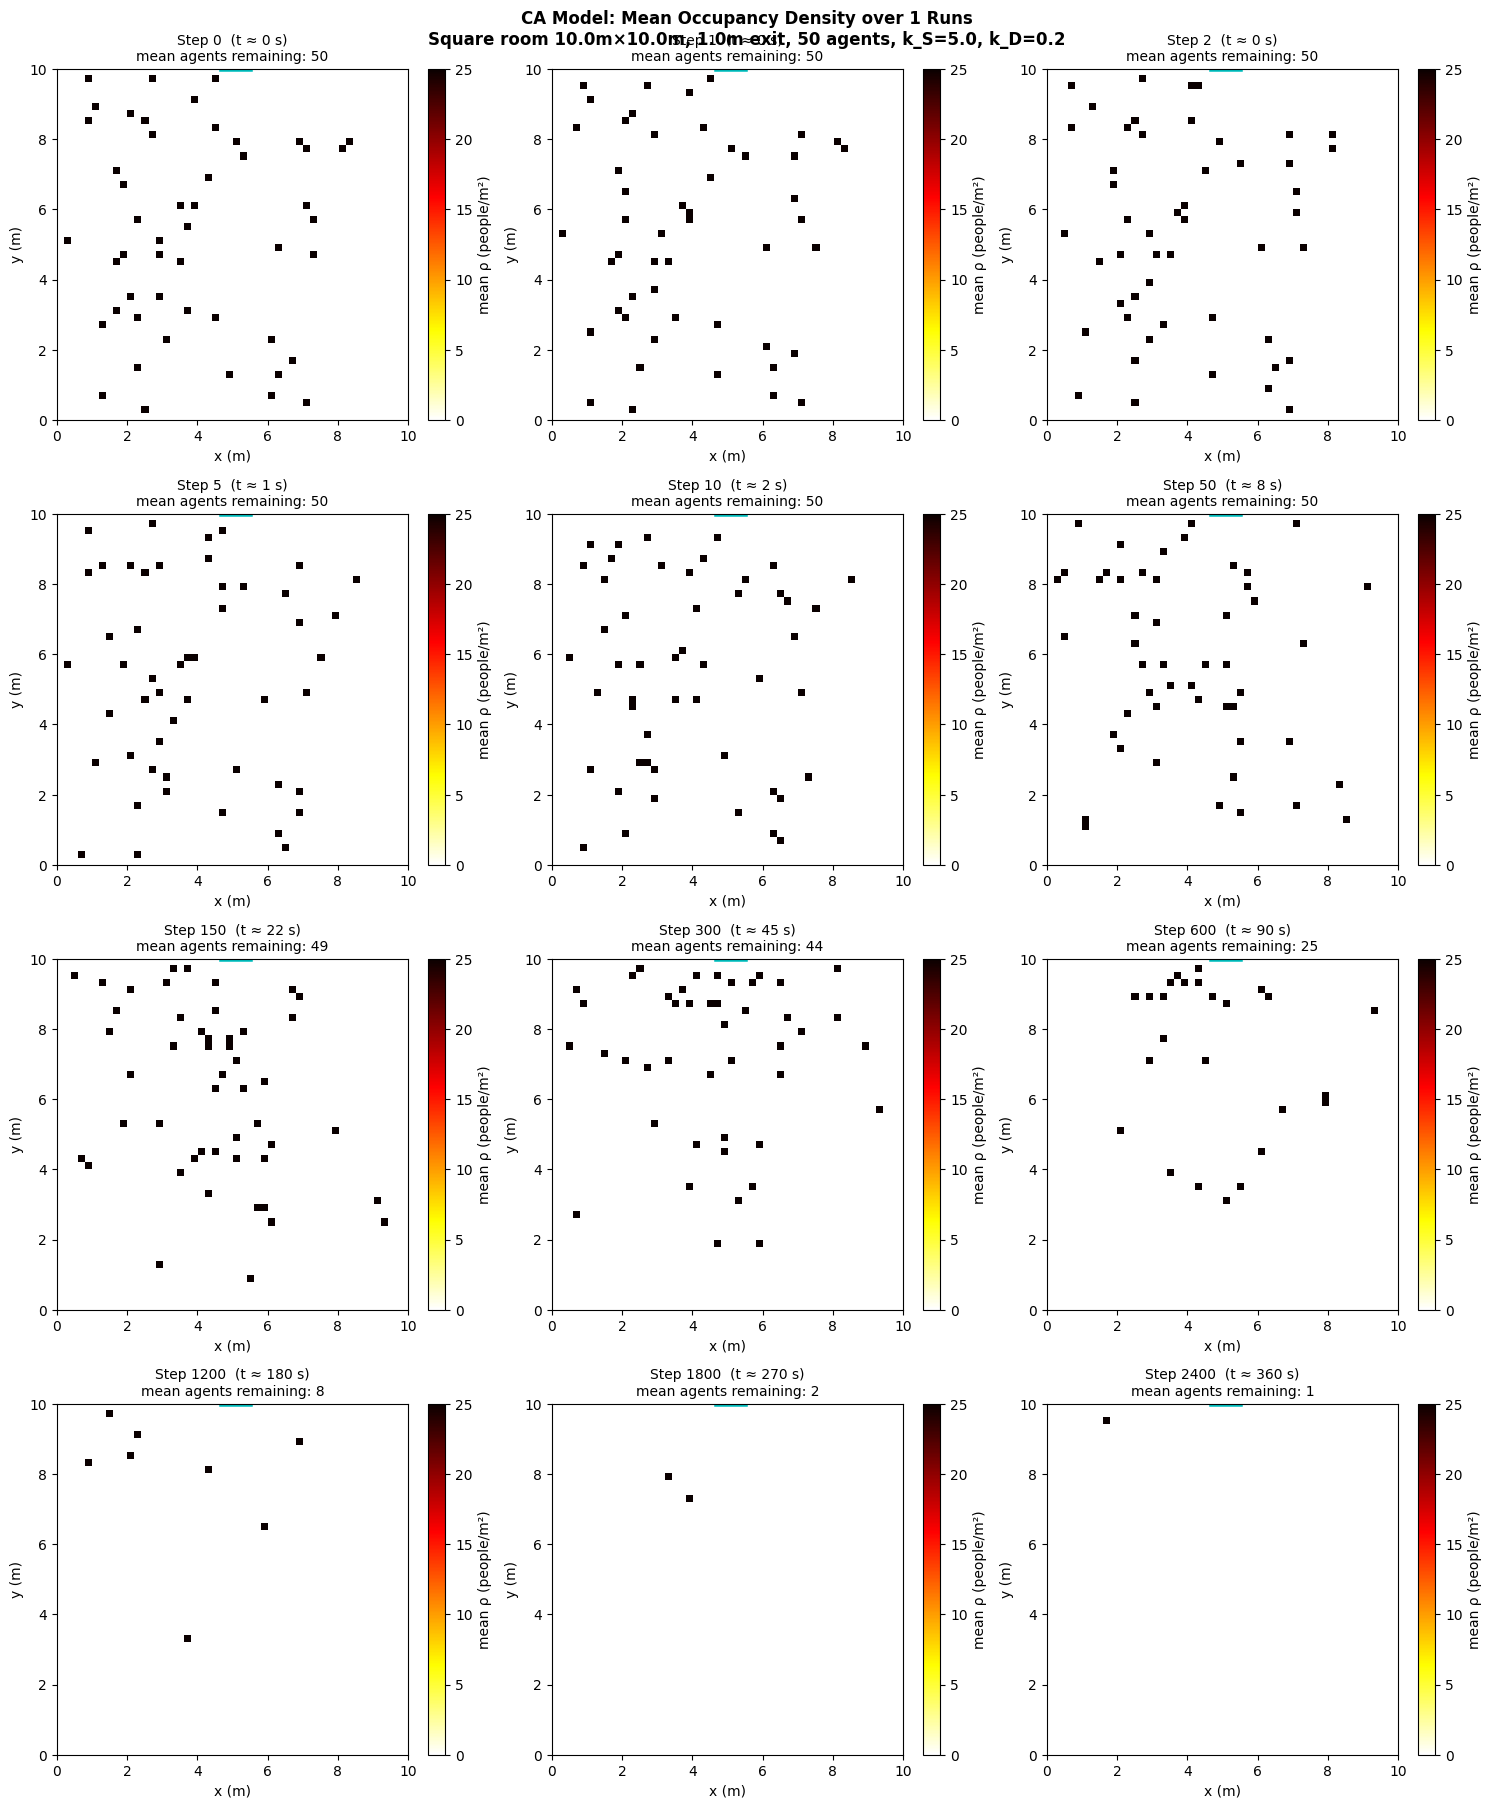

Snapshot figure saved as 'ca_snapshots.png'


In [32]:
# ── Snapshot plots: mean occupancy density ─────────────────────────────────────
cmap_occ = plt.cm.hot_r

n_plots = len(recorded_steps)
ncols   = 3
nrows   = (n_plots + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows))
axes = np.array(axes).flatten()

for ax, step_key in zip(axes, sorted(recorded_steps)):
    grids = all_snapshots[step_key]
    if not grids:
        ax.set_visible(False); continue
    mean_grid = np.mean(grids, axis=0)          # mean occupancy ∈ [0,1]
    dens_grid = mean_grid / (CELL_SIZE**2)       # convert to people/m²
    vis = np.ma.masked_where(wall | exit_mask, dens_grid)
    im  = ax.imshow(vis, origin='lower', cmap=cmap_occ,
                    extent=[0, ROOM_W, 0, ROOM_H],
                    vmin=0, vmax=1/(CELL_SIZE**2), interpolation='nearest')
    plt.colorbar(im, ax=ax, label='mean ρ (people/m²)', fraction=0.046)
    t_phys = step_key * DT_PHYS
    n_rem  = int(round(np.sum(mean_grid) * len(grids[0].flatten()) / len(grids[0].flatten())))
    n_rem  = int(round(np.mean([np.sum(g) for g in grids])))
    ax.set_title(f'Step {step_key}  (t ≈ {t_phys:.0f} s)\n'
                 f'mean agents remaining: {n_rem}', fontsize=10)
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
    ax.plot([(ec0+0.5)*CELL_SIZE, (ec1-0.5)*CELL_SIZE], [ROOM_H, ROOM_H],
            'c-', lw=4)

for ax in axes[n_plots:]:
    ax.set_visible(False)

fig.suptitle(f'CA Model: Mean Occupancy Density over {N_RUNS} Runs\n'
             f'Square room {ROOM_W}m×{ROOM_H}m, {EXIT_W}m exit, '
             f'{N_AGENTS} agents, k_S={k_S}, k_D={k_D}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ca_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Snapshot figure saved as 'ca_snapshots.png'")

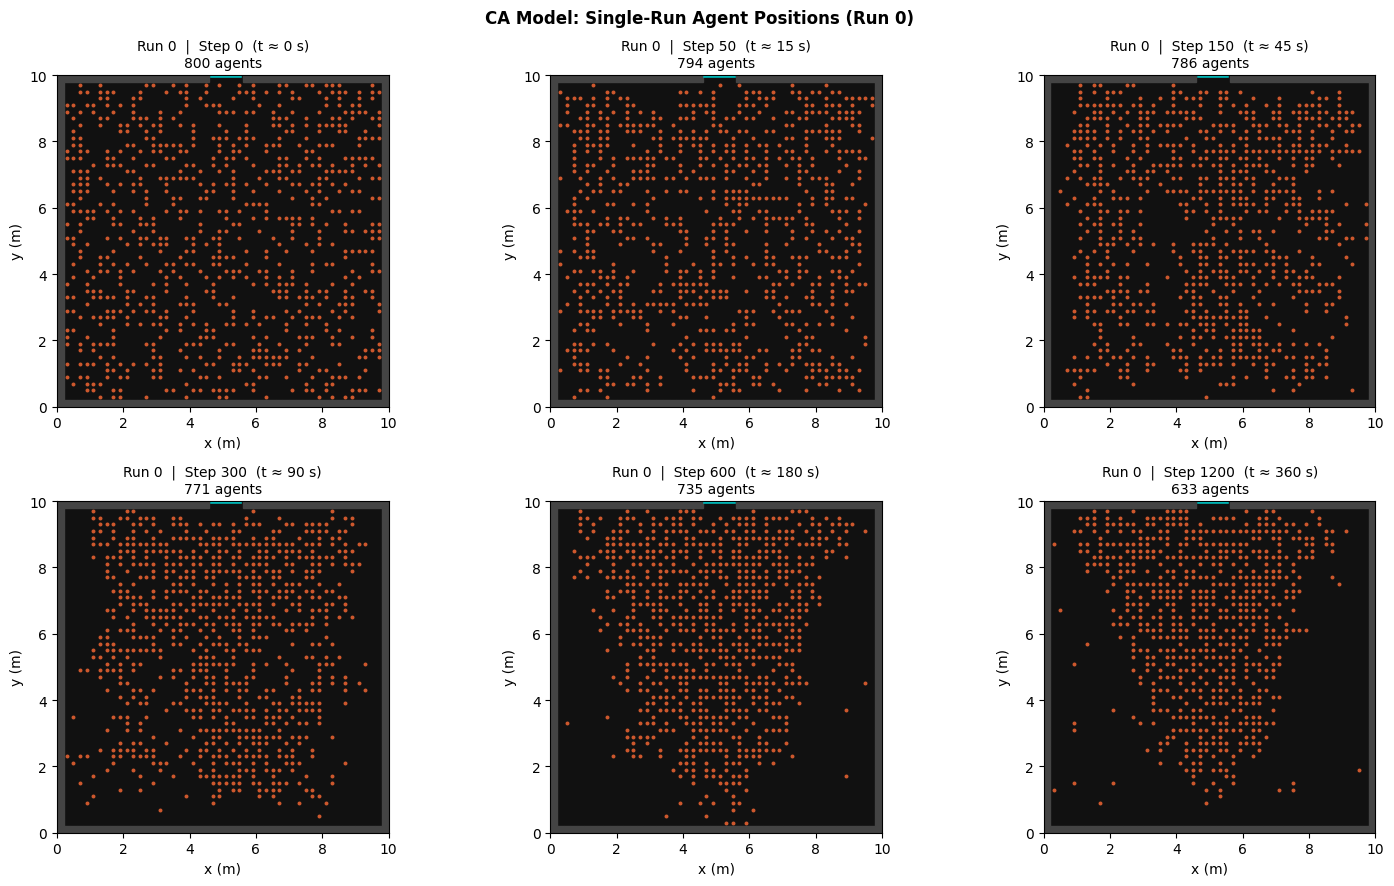

In [22]:
# ── Single-run snapshot: agent positions ───────────────────────────────────────
# Show what run 0 looked like at each snapshot time

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4.5*nrows))
axes = np.array(axes).flatten()

for ax, step_key in zip(axes, sorted(recorded_steps)):
    grids = all_snapshots[step_key]
    if not grids:
        ax.set_visible(False); continue
    g = grids[0]   # run 0
    rows, cols = np.where(g > 0)
    ax.set_xlim(0, ROOM_W); ax.set_ylim(0, ROOM_H)
    ax.set_facecolor('#111111')
    ax.scatter((cols + 0.5)*CELL_SIZE, (rows + 0.5)*CELL_SIZE,
               s=8, c='#FF6B35', alpha=0.8, linewidths=0)
    # Draw walls
    for r in range(M):
        for c in range(M):
            if wall[r,c]:
                ax.add_patch(plt.Rectangle((c*CELL_SIZE, r*CELL_SIZE),
                             CELL_SIZE, CELL_SIZE, color='#444'))
    # Exit
    ax.plot([(ec0+0.5)*CELL_SIZE, (ec1-0.5)*CELL_SIZE], [ROOM_H, ROOM_H],
            'c-', lw=4)
    t_phys = step_key * DT_PHYS
    ax.set_title(f'Run 0  |  Step {step_key}  (t ≈ {t_phys:.0f} s)\n'
                 f'{int(np.sum(g))} agents', fontsize=10)
    ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
    ax.set_aspect('equal')

for ax in axes[n_plots:]:
    ax.set_visible(False)

fig.suptitle('CA Model: Single-Run Agent Positions (Run 0)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('ca_agent_positions.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# ── Animation (run 0) ─────────────────────────────────────────────────────────
fig_a, ax_a = plt.subplots(figsize=(6, 6))
ax_a.set_facecolor('#111111')
ax_a.set_xlim(0, ROOM_W); ax_a.set_ylim(0, ROOM_H)

# Draw walls once
for r in range(M):
    for c in range(M):
        if wall[r, c]:
            ax_a.add_patch(plt.Rectangle((c*CELL_SIZE, r*CELL_SIZE),
                           CELL_SIZE, CELL_SIZE, color='#555'))

# Exit indicator
ax_a.plot([(ec0+0.5)*CELL_SIZE, (ec1-0.5)*CELL_SIZE], [ROOM_H, ROOM_H],
          'c-', lw=5, label='exit')
ax_a.legend(loc='lower right', fontsize=9)
ax_a.set_xlabel('x (m)'); ax_a.set_ylabel('y (m)')
ttl_a = ax_a.set_title('', fontsize=11)

scat = ax_a.scatter([], [], s=10, c='#FF6B35', alpha=0.85, linewidths=0)

def _ca_update(frame):
    step_f, grid_f = one_anim_frames[frame]
    rows, cols = np.where(grid_f > 0)
    xdata = (cols + 0.5) * CELL_SIZE
    ydata = (rows + 0.5) * CELL_SIZE
    scat.set_offsets(np.c_[xdata, ydata] if len(xdata) else np.empty((0,2)))
    n_rem = int(np.sum(grid_f))
    ttl_a.set_text(f'CA Model  |  Step {step_f}  '
                   f'(t ≈ {step_f*DT_PHYS:.0f} s)  |  {n_rem} agents')
    return [scat, ttl_a]

anim_ca = FuncAnimation(fig_a, _ca_update, frames=len(one_anim_frames),
                        interval=60, blit=True, repeat=True)
plt.close(fig_a)
print("Rendering CA animation...")
HTML(anim_ca.to_jshtml())

Rendering CA animation...
